In [69]:
import pandas as pd
import matplotlib.pyplot  as plt
from metrics import metrics
from model import generics
from scipy.stats import wilcoxon
pd.set_option('display.max_rows', 2000)
pd.set_option('display.max_columns', 2000)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [70]:
experiment_id = 'hourwindspeed'

In [76]:
df_mean_metrics, df_all_metrics, df_prevs = metrics.open_fold_result(experiment_id, normalize=False)

In [77]:
len([c for c in df_mean_metrics.reset_index()['model'].unique().tolist() if 'svrbagg1' in c])

0

In [78]:
df_mean_metrics.reset_index()['model'].unique()

array(['12mlp', '12mlppso1010', '12mlppso10100', '12mlppso1020',
       '12mlppso1050', '12mlppso110', '12mlppso120', '12mlppso150',
       '12mlppso2010', '12mlppso20100', '12mlppso2020', '12mlppso2050',
       '12mlppso3010', '12mlppso30100', '12mlppso3020', '12mlppso3050',
       '12mlppso510', '12mlppso520', '12mlppso550', '1arima', '1elm',
       '1kan', '1ma', '1mlp', '1mlppso1010', '1mlppso1020', '1mlppso1050',
       '1mlppso110', '1mlppso120', '1mlppso150', '1mlppso510',
       '1mlppso520', '1mlppso550', '1nhits', '1rw', '1svr', '1tcn',
       '24mlp'], dtype=object)

In [79]:
df_mean_metrics.columns

Index(['MSE', 'RMSE', 'MAPE', 'SMAPE', 'MAE', 'theil', 'ARV', 'IA', 'POCID',
       'val_metric', 'time_testing', 'time_training'],
      dtype='object')

In [80]:
df_mean_metrics.reset_index().sort_values(['ts', 'model'])[['ts', 'model', "MSE", 'MAPE', 'SMAPE', 'MAE', 'val_metric']]

,ts,model,MSE,MAPE,SMAPE,MAE,val_metric
0,windspeedcaruaruhour,12mlp,0.426167,23.159888,21.541011,0.504050,0.876417
1,windspeedcaruaruhour,12mlppso1010,0.424895,23.055708,21.475941,0.502541,NaN
2,windspeedcaruaruhour,12mlppso10100,0.427043,23.067754,21.556836,0.504365,NaN
3,windspeedcaruaruhour,12mlppso1020,0.425298,23.028996,21.491412,0.502748,NaN
4,windspeedcaruaruhour,12mlppso1050,0.425284,23.006427,21.496985,0.502903,NaN
5,windspeedcaruaruhour,12mlppso110,0.465210,24.438187,22.773317,0.531076,NaN
6,windspeedcaruaruhour,12mlppso120,0.460128,24.279649,22.618915,0.526984,NaN
7,windspeedcaruaruhour,12mlppso150,0.467481,24.515428,22.837393,0.532150,NaN
8,windspeedcaruaruhour,12mlppso2010,0.423410,23.110331,21.461825,0.502037,NaN
9,windspeedcaruaruhour,12mlppso20100,0.423808,22.933768,21.421465,0.501069,NaN


In [48]:
filters = df_mean_metrics.reset_index()['model'].isin(
    ['1arima',  '1kanval', '1ma', '1nhits', '1rw', '1svr', '1tcn', 'hmrc450k25',
     '1elm',
     #'1elmbagg500.80.8', '1elmbagg500.80.8k25', '1elmbagg500.80.8rc450k25',
     '1mlp', 
     #'1mlpbagg500.80.8', '1mlpbagg500.80.8k25', '1mlpbagg500.80.8rc450k25',
      '1svr', '1svrbagg500.80.8', '1svrbagg500.80.8rc100k20', '1svrbagg500.80.8k20',
      '1elm', '1elmbagg500.80.8', '1elmbagg500.80.8rc100k20', '1elmbagg500.80.8k20',
     'combmean', 'hmrc20k3'
     ])

In [17]:
#df_mean_metrics[filters.values].reset_index().sort_values(by=['ts', 'model'])[['ts', 'model', 'RMSE', 'SMAPE', 'MAE']]
df_mean_metrics.reset_index().sort_values(by=['ts', 'model'])[['ts', 'model', 'RMSE',  'MAE' ,'MAPE']]

,ts,model,RMSE,MAE,MAPE
0,windspeedcaruaruhour,1mlp,0.554973,0.419722,17.565553
1,windspeedcaruaruhour,1svr,0.552450,0.419236,17.617731
2,windspeedcastelodopiauihour,1mlp,0.441544,0.322940,15.540707
3,windspeedmaceiohour,1mlp,0.697808,0.536452,26.228248
4,windspeedsalvadorhour,1mlp,0.381408,0.272401,23.116508


In [9]:
metric = 'RMSE'

proposed_list = []
for k, df in df_mean_metrics.reset_index().groupby('ts'):
    #arima = df[df['model'] == 'arima'][metric].iloc[0]
    #svr = df[df['model'] == 'arima'][metric].iloc[0]
    #mlp = df[df['model'] == 'arima'][metric].iloc[0]

    #df_arima[k] = (df.set_index('model')[metric] < arima)
    #df_svr[k] = (df.set_index('model')[metric] < svr)
    #df_mlp[k] = (df.set_index('model')[metric] < mlp)

    svr_proposed = df[( (df['model'].str.contains("1ammeanenscdsrc12k10")))].copy()
    if svr_proposed.shape[0]>0:
        proposed_list.append(pd.DataFrame(svr_proposed.iloc[svr_proposed['val_metric'].argmin()]).T)

    mlp_proposed = df[( (df['model'].str.contains("mlpkpssfalsep")) )].copy()
    if mlp_proposed.shape[0]>0:
        proposed_list.append(pd.DataFrame(mlp_proposed.iloc[mlp_proposed['val_metric'].argmin()]).T)
    order_personalizada =  [ 
               #'1mlp', 
              
              #'1ammean100', 
              #'1as', 
              #'1asens', 
              ##'1am' ,
               '1aquant',
               '1aquantmean100', 
              
              #'1ammean100cdsrc0.1k20', '1ammean100cdsrc0.1k40', '1ammean100cdsrc0.1k80' , 
              #'1ammean100cmostrecentrc1k20', '1ammean100cmostrecentrc1k40', '1ammean100cmostrecentrc1k80', 
               '1aquantmean100cdsrc0.1k20', '1aquantmean100cdsrc0.1k40', '1aquantmean100cdsrc0.1k80',
               '1aquantmean100cmostrecentrc1k20', '1aquantmean100cmostrecentrc1k40', '1aquantmean100cmostrecentrc1k80', 
               #'1asenscdsrc0.1k20',  '1asenscdsrc0.1k40',  '1asenscdsrc0.1k80',
               #'1asenscmostrecentrc1k20',  '1asenscmostrecentrc1k40', '1asenscmostrecentrc1k80',
                '1arima',
                '1svr', 
            ]
    proposed_list.append(
        df[df['model'].isin(
            order_personalizada
        )]
    )

In [10]:
df_show = pd.concat(proposed_list)[['ts', 'model', 'RMSE', 'MAPE', 'MAE']]

df_show['model'] = pd.Categorical(df_show['model'], categories=order_personalizada, ordered=True)

In [11]:
df_show.sort_values(['ts', 'model'])

,ts,model,RMSE,MAPE,MAE
0,irradiacaocabrobo2024,1arima,371.991787,64.371981,265.795717
27,irradiacaocabrobo2024,1svr,342.296804,26.346885,229.935520
52,irradiacaoouricuri2024,1arima,461.221960,54.453734,333.859942
79,irradiacaoouricuri2024,1svr,383.086543,32.446668,261.982415
104,irradiacaosalgueiro2024,1arima,426.726329,51.503902,310.058879
131,irradiacaosalgueiro2024,1svr,399.187609,34.597228,285.589976
156,irradiancecastelopiaui,1arima,470.984653,54.932663,363.510360
182,irradiancecastelopiaui,1svr,431.498313,45.642288,322.125288
207,irradiancepicospi,1arima,270.753349,121.274950,208.265014
233,irradiancepicospi,1svr,269.251699,54.057725,192.424418


In [12]:
gen = 100
n_gen = 100
w_max = 0.5
w_min = 0.4
frac = (gen / n_gen)
w = w_max - (frac * (w_max - w_min))
w


0.4

('irradiacaocabrobo2024',)


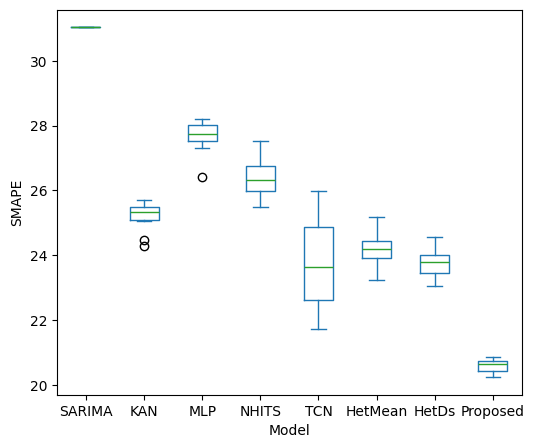

,base,1arima,1deepar,1elm,1elmbagg500.80.8,1elmbagg500.80.8k10,1elmbagg500.80.8k20,1elmbagg500.80.8k40,1elmbagg500.80.8k5,1elmbagg500.80.8rc100k10,1elmbagg500.80.8rc100k20,1elmbagg500.80.8rc100k40,1elmbagg500.80.8rc100k5,1elmbagg500.80.8rc200k10,1elmbagg500.80.8rc200k20,1elmbagg500.80.8rc200k40,1elmbagg500.80.8rc200k5,1elmbagg500.80.8rc25k10,1elmbagg500.80.8rc25k20,1elmbagg500.80.8rc25k40,1elmbagg500.80.8rc25k5,1elmbagg500.80.8rc50k10,1elmbagg500.80.8rc50k20,1elmbagg500.80.8rc50k40,1elmbagg500.80.8rc50k5,1kanval,1mlp,1nhits,1svr,1svrbagg500.80.8,1svrbagg500.80.8k10,1svrbagg500.80.8k20,1svrbagg500.80.8k40,1svrbagg500.80.8k5,1svrbagg500.80.8rc100k10,1svrbagg500.80.8rc100k20,1svrbagg500.80.8rc100k40,1svrbagg500.80.8rc100k5,1svrbagg500.80.8rc200k10,1svrbagg500.80.8rc200k20,1svrbagg500.80.8rc200k40,1svrbagg500.80.8rc200k5,1svrbagg500.80.8rc25k10,1svrbagg500.80.8rc25k20,1svrbagg500.80.8rc25k40,1svrbagg500.80.8rc25k5,1svrbagg500.80.8rc50k10,1svrbagg500.80.8rc50k20,1svrbagg500.80.8rc50k40,1svrbagg500.80.8rc50k5,1tcn,combmean,hmrc20k3
34,1svrbagg500.80.8rc100k20,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'=,'=,'+,'=,'+,'+,'+,'+,'=,'=,'+,'+,'=,'-,'+,'=,'+,'+,'+


('irradiacaoouricuri2024',)


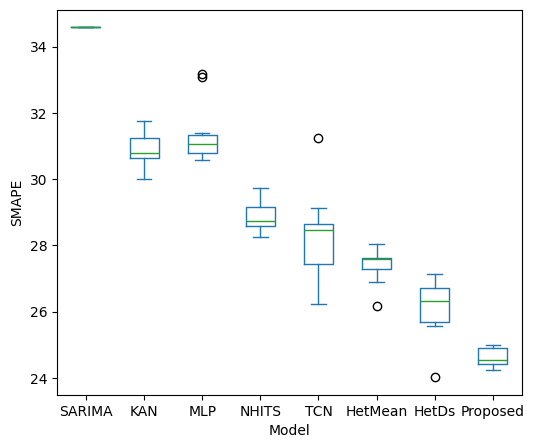

,base,1arima,1deepar,1elm,1elmbagg500.80.8,1elmbagg500.80.8k10,1elmbagg500.80.8k20,1elmbagg500.80.8k40,1elmbagg500.80.8k5,1elmbagg500.80.8rc100k10,1elmbagg500.80.8rc100k20,1elmbagg500.80.8rc100k40,1elmbagg500.80.8rc100k5,1elmbagg500.80.8rc200k10,1elmbagg500.80.8rc200k20,1elmbagg500.80.8rc200k40,1elmbagg500.80.8rc200k5,1elmbagg500.80.8rc25k10,1elmbagg500.80.8rc25k20,1elmbagg500.80.8rc25k40,1elmbagg500.80.8rc25k5,1elmbagg500.80.8rc50k10,1elmbagg500.80.8rc50k20,1elmbagg500.80.8rc50k40,1elmbagg500.80.8rc50k5,1kanval,1mlp,1nhits,1svr,1svrbagg500.80.8,1svrbagg500.80.8k10,1svrbagg500.80.8k20,1svrbagg500.80.8k40,1svrbagg500.80.8k5,1svrbagg500.80.8rc100k10,1svrbagg500.80.8rc100k20,1svrbagg500.80.8rc100k40,1svrbagg500.80.8rc100k5,1svrbagg500.80.8rc200k10,1svrbagg500.80.8rc200k20,1svrbagg500.80.8rc200k40,1svrbagg500.80.8rc200k5,1svrbagg500.80.8rc25k10,1svrbagg500.80.8rc25k20,1svrbagg500.80.8rc25k40,1svrbagg500.80.8rc25k5,1svrbagg500.80.8rc50k10,1svrbagg500.80.8rc50k20,1svrbagg500.80.8rc50k40,1svrbagg500.80.8rc50k5,1tcn,combmean,hmrc20k3
34,1svrbagg500.80.8rc100k20,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'=,'+,'+,'=,'+,'=,'=,'=,'+,'+,'=,'=,'+,'+,'=,'-,'+,'=,'-,'-,'+,'+,'+,'+


('irradiacaosalgueiro2024',)


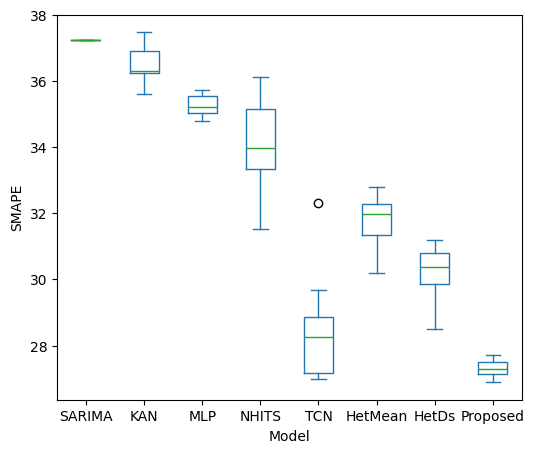

,base,1arima,1deepar,1elm,1elmbagg500.80.8,1elmbagg500.80.8k10,1elmbagg500.80.8k20,1elmbagg500.80.8k40,1elmbagg500.80.8k5,1elmbagg500.80.8rc100k10,1elmbagg500.80.8rc100k20,1elmbagg500.80.8rc100k40,1elmbagg500.80.8rc100k5,1elmbagg500.80.8rc200k10,1elmbagg500.80.8rc200k20,1elmbagg500.80.8rc200k40,1elmbagg500.80.8rc200k5,1elmbagg500.80.8rc25k10,1elmbagg500.80.8rc25k20,1elmbagg500.80.8rc25k40,1elmbagg500.80.8rc25k5,1elmbagg500.80.8rc50k10,1elmbagg500.80.8rc50k20,1elmbagg500.80.8rc50k40,1elmbagg500.80.8rc50k5,1kanval,1mlp,1nhits,1svr,1svrbagg500.80.8,1svrbagg500.80.8k10,1svrbagg500.80.8k20,1svrbagg500.80.8k40,1svrbagg500.80.8k5,1svrbagg500.80.8rc100k10,1svrbagg500.80.8rc100k20,1svrbagg500.80.8rc100k40,1svrbagg500.80.8rc100k5,1svrbagg500.80.8rc200k10,1svrbagg500.80.8rc200k20,1svrbagg500.80.8rc200k40,1svrbagg500.80.8rc200k5,1svrbagg500.80.8rc25k10,1svrbagg500.80.8rc25k20,1svrbagg500.80.8rc25k40,1svrbagg500.80.8rc25k5,1svrbagg500.80.8rc50k10,1svrbagg500.80.8rc50k20,1svrbagg500.80.8rc50k40,1svrbagg500.80.8rc50k5,1tcn,combmean,hmrc20k3
34,1svrbagg500.80.8rc100k20,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'=,'=,'=,'+,'+,'+,'+,'+,'=,'-,'=,'=,'=,'-,'=,'=,'+,'+,'+


('irradiancecastelopiaui',)


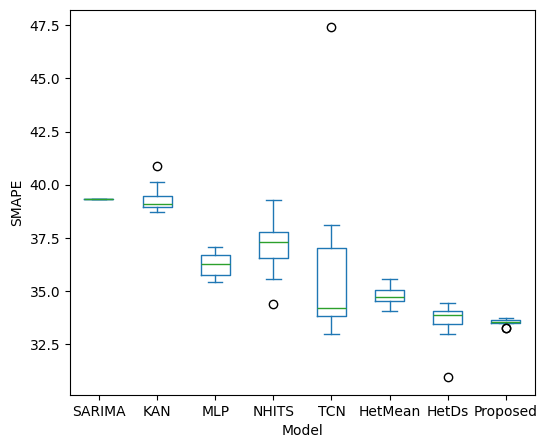

,base,1arima,1elm,1elmbagg500.80.8,1elmbagg500.80.8k10,1elmbagg500.80.8k20,1elmbagg500.80.8k40,1elmbagg500.80.8k5,1elmbagg500.80.8rc100k10,1elmbagg500.80.8rc100k20,1elmbagg500.80.8rc100k40,1elmbagg500.80.8rc100k5,1elmbagg500.80.8rc200k10,1elmbagg500.80.8rc200k20,1elmbagg500.80.8rc200k40,1elmbagg500.80.8rc200k5,1elmbagg500.80.8rc25k10,1elmbagg500.80.8rc25k20,1elmbagg500.80.8rc25k40,1elmbagg500.80.8rc25k5,1elmbagg500.80.8rc50k10,1elmbagg500.80.8rc50k20,1elmbagg500.80.8rc50k40,1elmbagg500.80.8rc50k5,1kanval,1mlp,1nhits,1svr,1svrbagg500.80.8,1svrbagg500.80.8k10,1svrbagg500.80.8k20,1svrbagg500.80.8k40,1svrbagg500.80.8k5,1svrbagg500.80.8rc100k10,1svrbagg500.80.8rc100k20,1svrbagg500.80.8rc100k40,1svrbagg500.80.8rc100k5,1svrbagg500.80.8rc200k10,1svrbagg500.80.8rc200k20,1svrbagg500.80.8rc200k40,1svrbagg500.80.8rc200k5,1svrbagg500.80.8rc25k10,1svrbagg500.80.8rc25k20,1svrbagg500.80.8rc25k40,1svrbagg500.80.8rc25k5,1svrbagg500.80.8rc50k10,1svrbagg500.80.8rc50k20,1svrbagg500.80.8rc50k40,1svrbagg500.80.8rc50k5,1tcn,combmean,hmrc20k3
33,1svrbagg500.80.8rc100k20,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'=,'+,'+,'=,'+,'+,'+,'=,'+,'+,'+,'-,'+,'+,'=,'=,'+,'=,'=,'=,'=,'+,'+,'=,'+,'-,'-,'-,'-,'-,'-,'-,'-,'+,'+,'=


('irradiancepicospi',)


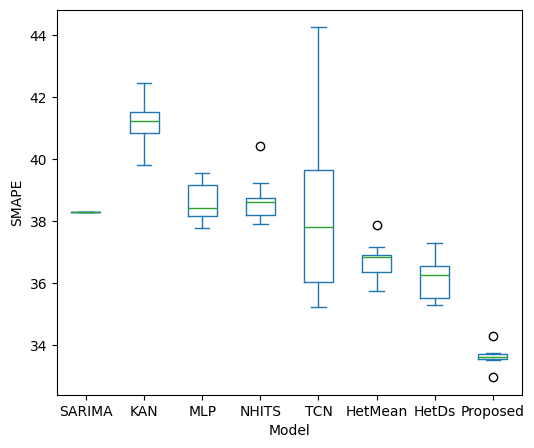

,base,1arima,1elm,1elmbagg500.80.8,1elmbagg500.80.8k10,1elmbagg500.80.8k20,1elmbagg500.80.8k40,1elmbagg500.80.8k5,1elmbagg500.80.8rc100k10,1elmbagg500.80.8rc100k20,1elmbagg500.80.8rc100k40,1elmbagg500.80.8rc100k5,1elmbagg500.80.8rc200k10,1elmbagg500.80.8rc200k20,1elmbagg500.80.8rc200k40,1elmbagg500.80.8rc200k5,1elmbagg500.80.8rc25k10,1elmbagg500.80.8rc25k20,1elmbagg500.80.8rc25k40,1elmbagg500.80.8rc25k5,1elmbagg500.80.8rc50k10,1elmbagg500.80.8rc50k20,1elmbagg500.80.8rc50k40,1elmbagg500.80.8rc50k5,1kanval,1mlp,1nhits,1svr,1svrbagg500.80.8,1svrbagg500.80.8k10,1svrbagg500.80.8k20,1svrbagg500.80.8k40,1svrbagg500.80.8k5,1svrbagg500.80.8rc100k10,1svrbagg500.80.8rc100k20,1svrbagg500.80.8rc100k40,1svrbagg500.80.8rc100k5,1svrbagg500.80.8rc200k10,1svrbagg500.80.8rc200k20,1svrbagg500.80.8rc200k40,1svrbagg500.80.8rc200k5,1svrbagg500.80.8rc25k10,1svrbagg500.80.8rc25k20,1svrbagg500.80.8rc25k40,1svrbagg500.80.8rc25k5,1svrbagg500.80.8rc50k10,1svrbagg500.80.8rc50k20,1svrbagg500.80.8rc50k40,1svrbagg500.80.8rc50k5,1tcn,combmean,hmrc20k3
33,1svrbagg500.80.8rc100k20,'+,'+,'+,'+,'+,'+,'+,'=,'+,'+,'=,'=,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'=,'=,'+,'=,'+,'+,'+,'+,'+,'=,'=,'=,'+,'+,'=,'+,'+,'+,'+


('irradiancevalencapiaui',)


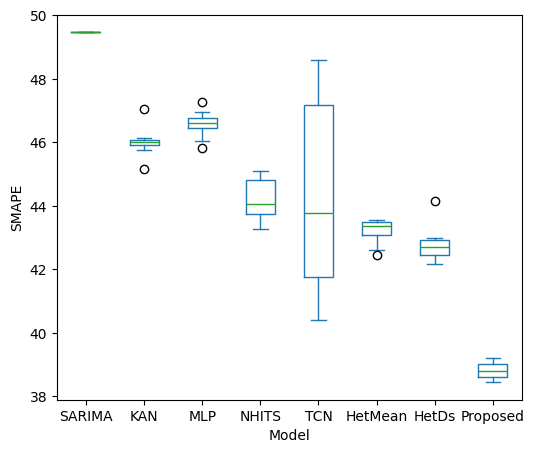

,base,1arima,1elm,1elmbagg500.80.8,1elmbagg500.80.8k10,1elmbagg500.80.8k20,1elmbagg500.80.8k40,1elmbagg500.80.8k5,1elmbagg500.80.8rc100k10,1elmbagg500.80.8rc100k20,1elmbagg500.80.8rc100k40,1elmbagg500.80.8rc100k5,1elmbagg500.80.8rc200k10,1elmbagg500.80.8rc200k20,1elmbagg500.80.8rc200k40,1elmbagg500.80.8rc200k5,1elmbagg500.80.8rc25k10,1elmbagg500.80.8rc25k20,1elmbagg500.80.8rc25k40,1elmbagg500.80.8rc25k5,1elmbagg500.80.8rc50k10,1elmbagg500.80.8rc50k20,1elmbagg500.80.8rc50k40,1elmbagg500.80.8rc50k5,1kanval,1mlp,1nhits,1svr,1svrbagg500.80.8,1svrbagg500.80.8k10,1svrbagg500.80.8k20,1svrbagg500.80.8k40,1svrbagg500.80.8k5,1svrbagg500.80.8rc100k10,1svrbagg500.80.8rc100k20,1svrbagg500.80.8rc100k40,1svrbagg500.80.8rc100k5,1svrbagg500.80.8rc200k10,1svrbagg500.80.8rc200k20,1svrbagg500.80.8rc200k40,1svrbagg500.80.8rc200k5,1svrbagg500.80.8rc25k10,1svrbagg500.80.8rc25k20,1svrbagg500.80.8rc25k40,1svrbagg500.80.8rc25k5,1svrbagg500.80.8rc50k10,1svrbagg500.80.8rc50k20,1svrbagg500.80.8rc50k40,1svrbagg500.80.8rc50k5,1tcn,combmean,hmrc20k3
33,1svrbagg500.80.8rc100k20,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'+,'-,'=,'=,'=,'+,'+,'+,'+,'-,'-,'=,'-,'-,'=,'=,'=,'+,'+,'+


In [15]:
def get_hipotesis(metrics_p1, metrics_p2):
    stat, p = wilcoxon(metrics_p1, metrics_p2, alternative='two-sided')
    # interpret
    alpha = 0.05
    if p > alpha:
        #print('Same distribution (fail to reject H0)')
        to_print = '\'='
    else:
        stat, p = wilcoxon(metrics_p1, metrics_p2, alternative='less')
        if p > alpha:
             to_print = '\'-'
        else:
            to_print = '\'+'
        #print('Different distribution (reject H0)')

    return to_print

def columns_x_columns(df_pivot):
    all_comparasion = []
    for c1 in df_pivot.columns:
        result_base = {}
        result_base['base'] = c1 
        for c2 in df_pivot.columns:
            if c1!=c2:
                result = get_hipotesis(df_pivot[c1], df_pivot[c2])
                result_base[c2] = result
            else:
                result_base[c2] = '\'='
        all_comparasion.append(result_base)
    
    df_result = pd.DataFrame(all_comparasion)
    
    display(df_result[df_result['base'] == '1svrbagg500.80.8rc100k20'])

all_execs = []
for key, df_serie in df_all_metrics.groupby(['ts']):
    print(key)
    df_pivot = df_serie.pivot(columns= 'model', values='SMAPE' )
    df_pivot = df_pivot.ffill()
    to_plot = df_serie.pivot(columns= 'model', values='SMAPE' )[[
        '1arima',
        '1kanval',
        '1mlp',
        '1nhits',
        '1tcn',
        'combmean',
        'hmrc20k3',
       '1svrbagg500.80.8rc100k20']
        ]
    
    ax = to_plot.rename(columns={
        '1arima': 'SARIMA',
        '1kanval': 'KAN',
        '1mlp': 'MLP',
        '1nhits':"NHITS",
        '1tcn': 'TCN',
        'combmean': 'HetMean',
        'hmrc20k3': 'HetDs',
       '1svrbagg500.80.8rc100k20': 'Proposed'
    }).plot.box(figsize = (6,5))
    ax.set_ylabel('SMAPE')
    ax.set_xlabel('Model')
    plt.savefig(f'box{key[0]}.pdf', format='pdf', bbox_inches='tight')
    plt.show()
    columns_x_columns(df_pivot)

In [14]:
df_all = df_all_metrics.reset_index()

In [74]:
df_all = df_all.pivot(index=['index', 'ts' ], values='RMSE', columns='model').groupby('ts').ffill().reset_index()

model,1arima,1deepar,1elm,1elmbagg100.60.6,1elmbagg100.60.8,1elmbagg100.80.6,1elmbagg100.80.8,1elmbagg200.60.6,1elmbagg200.60.8,1elmbagg200.80.6,...,1svrbagg500.80.8k5,1svrbagg500.80.8rc450k10,1svrbagg500.80.8rc450k25,1svrbagg500.80.8rc450k5,1svrbagg500.81,1svrbagg5010.6,1svrbagg5010.8,1svrbagg5011,1tcn,hmrc450k25
0,0.065864,0.091733,0.060708,0.061252,0.059818,0.063039,0.059487,0.060404,0.059918,0.060819,...,0.060557,0.059676,0.059420,0.059853,0.167696,0.246867,0.251136,0.242831,0.062580,0.060676
1,0.083665,0.114769,0.070103,0.080012,0.074704,0.069829,0.071241,0.072917,0.069326,0.071365,...,0.070949,0.067534,0.067506,0.067682,0.179699,0.240422,0.233753,0.237841,0.078254,0.070415
2,0.077837,0.106327,0.070698,0.070608,0.070371,0.071653,0.072250,0.073876,0.070600,0.071400,...,0.071055,0.068587,0.068594,0.068588,0.152732,0.234080,0.241720,0.235124,0.072215,0.070824
3,0.065864,0.096978,0.060734,0.060325,0.060221,0.064187,0.059343,0.062365,0.060260,0.059069,...,0.060433,0.059279,0.059472,0.059396,0.161090,0.251947,0.247616,0.247934,0.065672,0.063162
4,0.083665,0.110635,0.070156,0.073513,0.069673,0.069686,0.074280,0.068747,0.070590,0.071904,...,0.070734,0.067476,0.067559,0.067265,0.162198,0.244314,0.236863,0.234511,0.071601,0.071833
5,0.077837,0.107639,0.071228,0.072891,0.071757,0.076362,0.070898,0.070650,0.070391,0.076458,...,0.071382,0.068651,0.068586,0.068955,0.153408,0.235334,0.236697,0.234596,0.070648,0.072828
6,0.065864,0.101153,0.060712,0.061520,0.059628,0.063667,0.059264,0.064917,0.059754,0.059916,...,0.061146,0.059361,0.059554,0.059357,0.169963,0.235696,0.254330,0.238808,0.060471,0.062565
7,0.083665,0.144806,0.070311,0.075488,0.070078,0.067977,0.069300,0.071257,0.070659,0.071362,...,0.070847,0.067601,0.067593,0.067725,0.167859,0.245217,0.241129,0.237232,0.070076,0.074031
8,0.077837,0.107588,0.071030,0.075086,0.071490,0.072050,0.070750,0.072260,0.069971,0.074187,...,0.071174,0.068234,0.068429,0.068090,0.174111,0.233229,0.235118,0.234207,0.074670,0.072595
9,0.065864,0.096571,0.060953,0.065109,0.060018,0.062177,0.060103,0.060411,0.059636,0.061750,...,0.061227,0.059491,0.059372,0.059481,0.175240,0.261486,0.259896,0.259450,0.064657,0.062040


In [99]:
models = ['1arima', '1deepar', '1elm', 
       '1kanval', 
       '1mlp', 
      '1nhits', '1svr',    
       '1svrbagg500.80.8rc450k25', '1tcn',
       'hmrc450k25']

                           meanrank    median       mad  ci_lower  ci_upper  \
1svrbagg500.80.8rc450k25   1.066667  0.067710   0.00088   0.05942  0.068628   
1svr                       1.933333  0.067916  0.000956  0.060106  0.068872   
1elm                       3.433333  0.070076  0.000802  0.060734   0.07103   
1nhits                     4.100000  0.070342  0.000939  0.061707  0.071863   
hmrc450k25                 5.300000  0.071889  0.001127  0.062272  0.073284   
1tcn                       5.966667  0.071603  0.003864   0.06258  0.078065   
1mlp                       6.700000  0.073125  0.001386  0.065298  0.074708   
1kanval                    7.800000  0.076081   0.00129  0.064942  0.077762   
1arima                     8.700000  0.077837  0.005827  0.065864  0.083665   
1deepar                   10.000000  0.105822  0.008159  0.096571  0.144806   

                         effect_size   magnitude effect_size_above  \
1svrbagg500.80.8rc450k25         0.0  negligible            

<Figure size 1200x500 with 0 Axes>

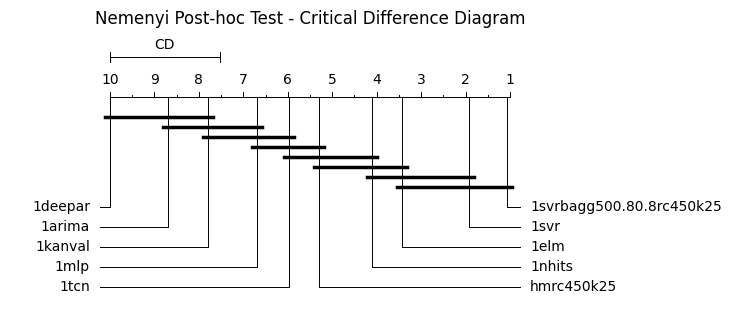


Ranks Médios:
                           meanrank    median       mad  ci_lower  ci_upper  \
1svrbagg500.80.8rc450k25   1.066667  0.067710   0.00088   0.05942  0.068628   
1svr                       1.933333  0.067916  0.000956  0.060106  0.068872   
1elm                       3.433333  0.070076  0.000802  0.060734   0.07103   
1nhits                     4.100000  0.070342  0.000939  0.061707  0.071863   
hmrc450k25                 5.300000  0.071889  0.001127  0.062272  0.073284   
1tcn                       5.966667  0.071603  0.003864   0.06258  0.078065   
1mlp                       6.700000  0.073125  0.001386  0.065298  0.074708   
1kanval                    7.800000  0.076081   0.00129  0.064942  0.077762   
1arima                     8.700000  0.077837  0.005827  0.065864  0.083665   
1deepar                   10.000000  0.105822  0.008159  0.096571  0.144806   

                         effect_size   magnitude effect_size_above  \
1svrbagg500.80.8rc450k25         0.0  negligi

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
from autorank import autorank, plot_stats
import numpy as np

# 1. Dados de exemplo (Substitua pelo seu DataFrame real)
# Cada coluna é um algoritmo, cada linha é um dataset/fold
data = df_all[models]
# 2. Executar o autorank
# Se os dados não forem normais, ele usará Friedman automaticamente.
# Se você quiser garantir o comportamento não-paramétrico, 
# o parâmetro correto para versões recentes é 'approach'.
result = autorank(data, alpha=0.05, verbose=False, order='ascending', approach='frequentist')

# 3. Gerar o gráfico de Diferença Crítica (CD Diagram)
# O autorank só gera o CD diagram se o teste de Friedman for significativo
if result.posthoc == 'nemenyi':
    plt.figure(figsize=(12, 5))
    plot_stats(result)
    plt.title("Nemenyi Post-hoc Test - Critical Difference Diagram")
    plt.show()
else:
    print(f"O teste post-hoc detectado foi: {result.posthoc}")
    print("Para gerar o CD diagram, o autorank precisa detectar dados não-paramétricos.")
    # Forçando o plot mesmo assim (se disponível para o teste detectado)
    plot_stats(result)
    plt.show()

# 4. Ver os ranks médios calculados
print("\nRanks Médios:")
print(result.rankdf)

In [87]:
print(f"Valor da Diferença Crítica (CD): {result.cd}")


Valor da Diferença Crítica (CD): 5.413501985277554


In [89]:
# 1. O P-Value do teste global (Friedman)
print(f"P-value do Teste de Friedman: {result.pvalue}")

# 2. Ver se a diferença é significante (Comparando p-value com alpha)
is_significant = result.pvalue < 0.05
print(f"Existe diferença estatística global? {is_significant}")

P-value do Teste de Friedman: 3.759820254540452e-100
Existe diferença estatística global? True
